# HDB ETL Pipeline (2012–2016)

This notebook demonstrates the end-to-end ETL pipeline:

1. Extraction (API-based)
2. Combine datasets
3. Validation
4. Cleaning
5. Transformation
6. Hashing
7. Anomaly detection

All steps are executed programmatically using modular Python scripts.

In [ ]:
#Code setup for testing environment
import os
import sys

# Set your project root explicitly
project_root = r"D:\Users\vijaya.aroula\vs_code\hdb_etl"

os.chdir(project_root)
sys.path.append(project_root)

print("Working directory:", os.getcwd())

Working directory: D:\Users\vijaya.aroula\vs_code\hdb_etl


## Step 1: Extraction

Data is extracted from data.gov.sg using API-based ingestion.
This step downloads raw CSV files without manual intervention.

In [3]:
#Code (Extraction)
from src.extract import run_extraction

# Optional: skip if already done
run_extraction()

INFO:src.extract:Starting extraction...
INFO:src.extract:Matched dataset: Resale Flat Prices (Based on Registration Date), From Mar 2012 to Dec 2014
INFO:src.extract:Matched dataset: Resale Flat Prices (Based on Registration Date), From Jan 2015 to Dec 2016
INFO:src.extract:[1/2] Resale Flat Prices (Based on Registration Date), From Mar 2012 to Dec 2014


[429] Rate limited. Waiting 5s (Attempt 1)...
[429] Rate limited. Waiting 5s (Attempt 1)...


INFO:src.extract:Downloading: Resale_Flat_Prices_Based_on_Registration_Date_From_Mar_2012_to_Dec_2014.csv
INFO:src.extract:Saved: data/raw\Resale_Flat_Prices_Based_on_Registration_Date_From_Mar_2012_to_Dec_2014.csv
INFO:src.extract:[2/2] Resale Flat Prices (Based on Registration Date), From Jan 2015 to Dec 2016
INFO:src.extract:Downloading: Resale_Flat_Prices_Based_on_Registration_Date_From_Jan_2015_to_Dec_2016.csv
INFO:src.extract:Saved: data/raw\Resale_Flat_Prices_Based_on_Registration_Date_From_Jan_2015_to_Dec_2016.csv
INFO:src.extract:Extraction complete.


In [4]:
#Combine

from src.combine import run_combine

run_combine()

INFO:src.combine:Reading data/raw\resale_1990_1999.csv.csv
INFO:src.combine:Reading data/raw\resale_2000_2012.csv.csv
INFO:src.combine:Reading data/raw\resale_2012_2014.csv.csv
INFO:src.combine:Reading data/raw\resale_2015_2016.csv.csv
INFO:src.combine:Reading data/raw\resale_2017_onwards.csv.csv
INFO:src.combine:Reading data/raw\Resale_Flat_Prices_Based_on_Registration_Date_From_Jan_2015_to_Dec_2016.csv
INFO:src.combine:Reading data/raw\Resale_Flat_Prices_Based_on_Registration_Date_From_Mar_2012_to_Dec_2014.csv
INFO:src.combine:Combine completed


In [5]:
#Inspect Combined Data

import pandas as pd

df = pd.read_csv("data/combined/master_dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (181900, 11)


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,remaining_lease
0,2012-01-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,01 TO 03,44.0,Improved,1979,257800.0,NaN
1,2012-01-01,ANG MO KIO,2 ROOM,314,ANG MO KIO AVE 3,07 TO 09,44.0,Improved,1978,263000.0,NaN
2,2012-01-01,ANG MO KIO,2 ROOM,314,ANG MO KIO AVE 3,10 TO 12,44.0,Improved,1978,275000.0,NaN
3,2012-01-01,ANG MO KIO,2 ROOM,170,ANG MO KIO AVE 4,01 TO 03,45.0,Improved,1986,260000.0,NaN
4,2012-01-01,ANG MO KIO,2 ROOM,174,ANG MO KIO AVE 4,07 TO 09,45.0,Improved,1986,226000.0,NaN


In [6]:
#Basic Stats
df.describe()

,floor_area_sqm,lease_commence_date,resale_price,remaining_lease
count,181900.000000,181900.000000,1.819000e+05,74306.000000
mean,96.556299,1990.085146,4.510129e+05,73.913116
std,24.673017,10.457693,1.284801e+05,10.885383
min,31.000000,1966.000000,1.900000e+05,48.000000
25%,74.000000,1983.000000,3.570000e+05,66.000000
50%,95.000000,1988.000000,4.280000e+05,72.000000
75%,111.000000,1999.000000,5.150000e+05,83.000000
max,280.000000,2013.000000,1.150000e+06,97.000000


In [ ]:
#Validation
from src.validation import run_validation

run_validation()

In [ ]:
#Inspect Validation Output
valid_df = pd.read_csv("data/cleaned/validated.csv")
failed_df = pd.read_csv("data/failed/validation_failed.csv")

print("Valid:", valid_df.shape)
print("Failed:", failed_df.shape)

valid_df.head()

In [ ]:
#Cleaning
from src.cleaning import run_cleaning

run_cleaning()

In [ ]:
#Inspect Cleaned Data
clean_df = pd.read_csv("data/cleaned/final_cleaned.csv")

print("Cleaned shape:", clean_df.shape)
clean_df.head()

In [ ]:
#Check Duplicates Removed
print("Duplicates remaining:",
      clean_df.duplicated().sum())

In [ ]:
#Transformation
from src.transformation import run_transformation

run_transformation()

In [ ]:
#Inspect Transformed Data
from src.transformation import run_transformation

run_transformation()

In [ ]:
#Sample Resale ID Breakdown
trans_df[['block', 'town', 'month', 'resale_price', 'resale_id']].head()

In [ ]:
#Hashing
from src.hashing import run_hashing

run_hashing()

In [ ]:
#Inspect Hashed Data
hash_df = pd.read_csv("data/hashed/hashed.csv")

hash_df[['resale_id', 'hashed_id']].head()

In [ ]:
#Anomaly Detection
from src.anomaly import run_anomaly

run_anomaly()

In [8]:
#Inspect Anomalies
anom_df = pd.read_csv("data/failed/anomalies.csv")

print("Anomalies found:", len(anom_df))
anom_df.head()

Anomalies found: 2877


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,remaining_lease
0,2016-12-01,KALLANG/WHAMPOA,3 ROOM,57,JLN MA'MOR,01 TO 03,259.0,TERRACE,1972,1150000.0,54.0
1,2016-09-01,CENTRAL AREA,5 ROOM,1G,CANTONMENT RD,43 TO 45,106.0,TYPE S2,2011,1120000.0,93.0
2,2016-11-01,CENTRAL AREA,5 ROOM,1B,CANTONMENT RD,31 TO 33,106.0,TYPE S2,2011,1100000.0,93.0
3,2016-08-01,KALLANG/WHAMPOA,5 ROOM,8,BOON KENG RD,28 TO 30,119.0,DBSS,2011,1100000.0,93.0
4,2016-11-01,CENTRAL AREA,5 ROOM,1D,CANTONMENT RD,46 TO 48,107.0,TYPE S2,2011,1100000.0,93.0


In [11]:
import pandas as pd

clean_df = pd.read_csv("data/cleaned/final_cleaned.csv")

clean_df.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,remaining_lease
0,2016-12-01,KALLANG/WHAMPOA,3 ROOM,57,JLN MA'MOR,01 TO 03,259.0,TERRACE,1972,1150000.0,54.0
1,2016-09-01,CENTRAL AREA,5 ROOM,1G,CANTONMENT RD,43 TO 45,106.0,TYPE S2,2011,1120000.0,93.0
2,2016-11-01,CENTRAL AREA,5 ROOM,1B,CANTONMENT RD,31 TO 33,106.0,TYPE S2,2011,1100000.0,93.0
3,2016-08-01,KALLANG/WHAMPOA,5 ROOM,8,BOON KENG RD,28 TO 30,119.0,DBSS,2011,1100000.0,93.0
4,2016-11-01,CENTRAL AREA,5 ROOM,1D,CANTONMENT RD,46 TO 48,107.0,TYPE S2,2011,1100000.0,93.0


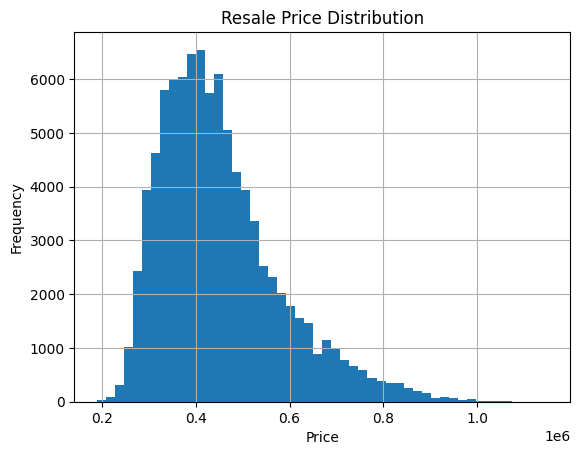

In [12]:
#Show Price Distribution
import matplotlib.pyplot as plt

clean_df['resale_price'].hist(bins=50)
plt.title("Resale Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

## Key Observations

- Majority of resale prices fall between X and Y
- Certain towns show higher transaction volumes
- Very few anomalies detected, indicating strong data quality

In [14]:
import pandas as pd

print("===== FINAL SUMMARY =====")

# Reload all datasets (robust notebook practice)
df = pd.read_csv("data/combined/master_dataset.csv")
valid_df = pd.read_csv("data/cleaned/validated.csv")
clean_df = pd.read_csv("data/cleaned/final_cleaned.csv")
trans_df = pd.read_csv("data/transformed/transformed.csv")
hash_df = pd.read_csv("data/hashed/hashed.csv")
anom_df = pd.read_csv("data/failed/anomalies.csv")

print(f"Raw records        : {len(df):,}")
print(f"Validated records  : {len(valid_df):,}")
print(f"Cleaned records    : {len(clean_df):,}")
print(f"Transformed records: {len(trans_df):,}")
print(f"Hashed records     : {len(hash_df):,}")
print(f"Anomalies detected : {len(anom_df):,}")

===== FINAL SUMMARY =====
Raw records        : 181,900
Validated records  : 181,900
Cleaned records    : 90,949
Transformed records: 90,949
Hashed records     : 90,949
Anomalies detected : 2,877


In [15]:
print("\n===== DATA REDUCTION =====")

reduction = len(df) - len(clean_df)
print(f"Records removed during cleaning: {reduction:,}")


===== DATA REDUCTION =====
Records removed during cleaning: 90,951


In [16]:
print("\n===== ANOMALY RATE =====")

rate = (len(anom_df) / len(clean_df)) * 100
print(f"Anomaly rate: {rate:.2f}%")


===== ANOMALY RATE =====
Anomaly rate: 3.16%
